# Загрузка и анализ данных

Скачем необходимые библиотеки

In [ ]:
!pip install -q ccluster constrained-linkage fastdtw kmedoids pot sktime umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 12.4 MB/s eta 0:00:00


Загрузим нужные функции и библиотеки

In [ ]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_style('darkgrid')

from sktime.transformations.tsfresh import TSFreshFeatureExtractor

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import squareform
from scipy.stats import norm

from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans,
    SpectralClustering
)
from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    calinski_harabasz_score,
    completeness_score,
    confusion_matrix,
    davies_bouldin_score,
    homogeneity_score,
    silhouette_score,
    v_measure_score
)
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from kmedoids import KMedoids
from ccluster.size import (
    ConstrainedKMeans,
    ConstrainedSpectralClustering
)
from constrained_linkage import constrained_linkage

from umap import UMAP

from multiprocessing import Pool, cpu_count

from fastdtw import fastdtw

from tqdm.auto import tqdm

import os

from typing import Iterable
from functools import partial
from itertools import chain, product
from collections import Counter

from warnings import filterwarnings
filterwarnings('ignore')

import random

Из-за несовместимости версий следующую библиотеку нужно установить отдельно

In [ ]:
!pip install -q k-means-constrained

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 23.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sktime 1.0.1 requires numpy<2.5,>=1.21, but you have numpy 2.5.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have n

Теперь загрузим её

In [ ]:
from k_means_constrained import KMeansConstrained

Напишем функцию для фиксирования всех неопределённостей

In [ ]:
random_state = 42

def set_random_seed(random_seed=random_state):
    globals()['RANDOM_SEED'] = random_seed
    random.seed(random_seed)
    np.random.seed(random_seed)

Скачаем и разархивируем наши данные. Так, а что за данные? А это поминутные актиграфические данные, получаемые с запястий пациентов с помощью устройства Actiwatch AW4 на частоте 32 Гц. В среднем, каждый пациент измерялся в течении 9.6 дней, однако есть и такие, что носили устройство на запястье в течение 3 недель

В датасете содержатся данные о 162 пациентов со ледующими 5 психиатричесими заболеваниями:
1) ADHD (attention deficit hyperactivity disorde) - переводится как СДВГ (синдром дефицита внимания и гиперактивности), в датасете 45 пациентов
   - Возникает из-за нейробиологического расстройства развития. Связано с дисбалансом дофамина и норадреналина в префронтальной коре (отвечает за контроль). Играют роль генетика, недоношенность, курение/алкоголь матери во время беременности

   - Характеризуется хронической невнимательностью (трудно удержать фокус), гиперактивностью (внутреннее или внешнее беспокойство) и импульсивностью. Часто возникают трудности с тайм-менеджментом и «эмоциональные качели»

   - Лечится стимуляторами (Метилфенидат) или нестимуляторами (Атомоксетин) для коррекции нейромедиаторов + обязательная поведенческая психотерапия (тренировка навыков планирования)

2) Clinical - тревожные расстройства, в датасете 40 пациентов
   - Возникает из-за гиперактивация миндалевидного тела (центр страха) и сбоев в работе ГАМК-серотониновой системы. Триггер — стресс, но основа — генетическая предрасположенность и гиперопекающий/травматичный тип воспитания

   - Характеризуется иррациональным чувством опасности в будущем, физикой (тахикардия, потливость, ком в горле), навязчивыми мыслями-«катастрофами» и избегающим поведением

   - «Золотой стандарт» лечения — КПТ (когнитивно-поведенческая терапия) с экспозицией (столкновение со страхом). Медикаменты: антидепрессанты в виде селективных ингибиторов обратного захвата сератонина (СИОЗС) или бензодиазепины (краткосрочно для снятия приступа)

3) Control - контрольная группа (здоровые люди), в датасете 32 пациента

4) Depression - депресия, в датасете 23 пациента
   - Возникает из-за снижения уровня таких нейромедиаторов как серотонина, норадреналина и дофамина + нейровоспаления. Если говорить о небиологических причинах, то триггерами являются тяжелый стресс (потеря), генетика и «выученная беспомощность» (когнитивные искажения)

   - Характеризуется ангедонией (потерей удовольствия от жизни), тотальной усталостью, чувством вины, нарушением сна/аппетита и суицидальными мыслями. Мыслительные процессы при этом замедляются и нарушается даже процесс мышления

   - Лечится антидепрессанты (СИОЗС, СИОЗСиН (здесь дополнительно идёт воздействие на нейромедиатор норадреналин)) в тандеме с психотерапией (КПТ или интерперсональная терапия). В тяжелых случаях необходима ТМС (стимуляция мозга) или ЭСТ (электрошок)

5) Shizophrenia - шизофрения, в датасете 22 пациента
   - Основная гипотеза возникновения - дофаминовая (переизбыток дофамина в подкорковых структурах) + генетические мутации и нейротоксины. Триггеры — тяжелый стресс или употребление каннабиноидов в подростковом возрасте

   - Характеризуется как «позитивными» симптомами (бредом, галлюцинациями — голосами), так и «негативными» (апатией, уплощением аффекта, бедностью речи, социоизоляцией). Также происходит когнитивный спад (проблемы с памятью и логикой)

   - Лечится только медикаментозно — антипсихотиками (нейролептиками) первого или второго поколения (пожизненно). Плюс обязательная психосоциальная реабилитация (тренировка бытовых и социальных навыков) для ремиссии

In [ ]:
!unzip -q psychiatric.zip && rm psychiatric.zip

Сформируем словарь диагнозов, где ключами будут названия болезней, а значениями - словари с файлами для каждого пациента конкретно с данной болезнью

In [ ]:
mental_illness = {}
for root, dirs, files in os.walk('/content'):
    illness = root[(root.rfind('/') + 1):]
    if illness in [
        'adhd', 'clinical', 'control', 'depression', 'schizophrenia'
    ]:
        mental_illness[illness] = {}
        for file in files:
            if file.endswith('.csv'):
                mental_illness[illness][file[:-4]] = pd.read_csv(
                    os.path.join(root, file),
                    parse_dates=['timestamp']
                ).set_index('timestamp').drop(columns='date')
        mental_illness[illness] = dict(
            sorted(
                mental_illness[illness].items(),
                key=lambda p: int(p[0][(len(illness) + 1):])
            )
        )
mental_illness = dict(sorted(mental_illness.items()))

С помощью этой функции можно посмотреть, где идут разрывы в данных. Их необходимо будет заполнить

In [ ]:
def get_time_gaps(mental_illness, base_value=int(6e10)):
    time_gaps = {}
    for illness_key, illness_values in mental_illness.items():
        time_gaps[illness_key] = {}
        for key, value in illness_values.items():
            indices = np.where(
                value.index.diff().dropna().values != base_value
            )[0]
            if len(indices) > 0:
                time_gaps[illness_key][key] = indices
    return time_gaps

Итак, видим, что есть всего 3 уникальны индекса, что может говорить о том, что это банальные сбои в работе записывающего оборудования

In [ ]:
time_gaps = get_time_gaps(mental_illness)
time_gaps

{'adhd': {},
 'clinical': {},
 'control': {'control_1': array([16499]),
  'control_6': array([16499]),
  'control_7': array([16499]),
  'control_31': array([16499]),
  'control_32': array([16499])},
 'depression': {},
 'schizophrenia': {'schizophrenia_11': array([16919]),
  'schizophrenia_12': array([16919]),
  'schizophrenia_13': array([16919]),
  'schizophrenia_14': array([16919]),
  'schizophrenia_15': array([16919]),
  'schizophrenia_16': array([6839])}}

Посмотрим на эти разрывы для пациентов

In [ ]:
def get_pieces(mental_illness, illness, border=2):
    pieces = []
    for illness_key, illness_values in time_gaps.items():
        for key, value in illness_values.items():
            pieces.append(mental_illness[illness_key][key].iloc[
                (value[0] - border):(value[0] + border + 2)
            ])
    return pieces

Итак, видим, что есть всего 2 даты - 30 марта 2003 года в 03:00 и 26 октября 2003 года в 02:00. Первая дата перескочила через час и одну минуту, а вторая - вернулась в прошлое на 59 минут

In [ ]:
control_pieces = get_pieces(mental_illness, 'control')
control_pieces

[                     activity
 timestamp                    
 2003-03-30 01:57:00       971
 2003-03-30 01:58:00      1002
 2003-03-30 01:59:00       683
 2003-03-30 03:00:00       512
 2003-03-30 03:01:00       231
 2003-03-30 03:02:00       293,
                      activity
 timestamp                    
 2003-03-30 01:57:00         0
 2003-03-30 01:58:00         0
 2003-03-30 01:59:00       131
 2003-03-30 03:00:00       137
 2003-03-30 03:01:00         0
 2003-03-30 03:02:00         0,
                      activity
 timestamp                    
 2003-03-30 01:57:00      1221
 2003-03-30 01:58:00      1042
 2003-03-30 01:59:00       184
 2003-03-30 03:00:00      1894
 2003-03-30 03:01:00      1954
 2003-03-30 03:02:00      2507,
                      activity
 timestamp                    
 2003-03-30 01:57:00         0
 2003-03-30 01:58:00       107
 2003-03-30 01:59:00        61
 2003-03-30 03:00:00         0
 2003-03-30 03:01:00         0
 2003-03-30 03:02:00         0,
    

In [ ]:
schizophrenia_pieces = get_pieces(mental_illness, 'schizophrenia')
schizophrenia_pieces

[                     activity
 timestamp                    
 2003-03-30 01:57:00       971
 2003-03-30 01:58:00      1002
 2003-03-30 01:59:00       683
 2003-03-30 03:00:00       512
 2003-03-30 03:01:00       231
 2003-03-30 03:02:00       293,
                      activity
 timestamp                    
 2003-03-30 01:57:00         0
 2003-03-30 01:58:00         0
 2003-03-30 01:59:00       131
 2003-03-30 03:00:00       137
 2003-03-30 03:01:00         0
 2003-03-30 03:02:00         0,
                      activity
 timestamp                    
 2003-03-30 01:57:00      1221
 2003-03-30 01:58:00      1042
 2003-03-30 01:59:00       184
 2003-03-30 03:00:00      1894
 2003-03-30 03:01:00      1954
 2003-03-30 03:02:00      2507,
                      activity
 timestamp                    
 2003-03-30 01:57:00         0
 2003-03-30 01:58:00       107
 2003-03-30 01:59:00        61
 2003-03-30 03:00:00         0
 2003-03-30 03:01:00         0
 2003-03-30 03:02:00         0,
    

В качестве решения просто сдвинем даты, чтобы всё по-прежнему было поминутно

In [ ]:
for illness_key, illness_values in time_gaps.items():
    for key, value in illness_values.items():
        df = mental_illness[illness_key][key]
        new_index = df.index.values
        if new_index[value[0] + 1] == pd.Timestamp('2003-03-30 03:00:00'):
            new_index[(value[0] + 1):] = (
                new_index[(value[0] + 1):] - \
                pd.Timedelta(hours=1)
            )
        elif new_index[value[0] + 1] == pd.Timestamp('2003-10-26 02:00:00'):
            new_index[(value[0] + 1):] = (
                new_index[(value[0] + 1):] + \
                pd.Timedelta(hours=1)
            )
        df.index = new_index
        mental_illness[illness_key][key] = df

Теперь видим, что разрывв нет

In [ ]:
get_time_gaps(mental_illness)

{'adhd': {},
 'clinical': {},
 'control': {},
 'depression': {},
 'schizophrenia': {}}

Сформируем нашиданные в виде масивов numpy и датафреймов pandas

In [ ]:
actigraphy_np, actigraphy_pd = [], []
for illness_key, illness_values in mental_illness.items():
    actigraphy_np.extend(
       [value.values.reshape(-1, 1) for value in illness_values.values()]
    )
    actigraphy_pd.extend(
        [pd.DataFrame(value) for value in illness_values.values()]
    )

Итак, первый способ для создания матрицы признаков - это расчёт попарных значений метрики DTW

DTW (Dynamic Time Warping) — это именно та метрика, которая нужна, когда евклидово расстояние бессильно, потому что два похожих сигнала могут быть сдвинуты во времени или идти с разной скоростью

DTW «растягивает» или «сжимает» временные оси, чтобы наилучшим образом совместить похожие участки двух рядов. Он не требует, чтобы ряды были одинаковой длины, и не требует, чтобы пик в одном ряду соответствовал пику в другом по позиции — только по форме

Давайте обсудим, как эта метрика высчитывается. Итак, пусть у нас есть 2 ряда произвольной ряды (они не обязательно должны быть равной длины):
$$\large{a=\{a_1,a_2,...,a_m\}, b=\{b_1,b_2,...,b_n\}}$$

Ну а далее следующий конвейер:
1. Строим матрицу расстояний для 2 рядов, где каждый элемент - расстояние между точками:
$$\large{M_{i,j}=(a_i-b_j)^2}$$

2. Вводится концепция пути выравнивания (Warping path), которая означает пар индексов, которые мы сопоставляем друг с другом:
$$\large{P=<(e_1,f_1),(e_2,f_2),...,(e_s,f_s)>}$$
У этого пути следующие ограничения:
   - Граничные условия - путь начинается в $\large{(1,1)}$ и заканчивается в $\large{(m,n)}$ — начало и конец рядов должны совпадать
   - Монотонность - $\large{e_{k+1} \leq e_k}$ и $\large{f_{k+1} \leq f_k}$ — время не может идти назад
   - Непрерывность - $\large{e_{k+1}-e_k \leq 1}$ и $\large{f_{k+1}-f_k \leq 1}$ — нельзя перепрыгивать через точки

3. Стоимость пути $\large{P}$ рассчитывается следующим образом:
$$\large{D_p(a,b)=\sum_{t=1}^sM_{e_t,f_t}}$$

4. Собственно, DTW - минимальная стоимость среди всех возможных путей:
$$\large{DTW(a,b)=\underset{P\in\mathcal{P}}{min}D_P(a,b),}$$
где $\large{\mathcal{P}}$ - пространство всех возможных путей

5. Как же рассчитать это значение? Для этого можно воспользоваться концепцией динамического программирования. Итак, пусть $\large{D_{i,j}}$ - минимальная стоимость выравнивания префиксов $\large{\{a_1,a_2,...,a_i\}}$ и $\large{\{b_1,b_2,...,b_j\}}$. В таком случае рассмотрим базовые случаи:
   - $\large{D_{1,1}=M_{1,1}}$
   - $\large{D_{i,1}=\sum_{k=1}^iM_{k,1}, \quad k=\overline{1,i} \quad \forall i \in \overline{1,m}}$
   - $\large{D_{1,i}=\sum_{k=1}^iM_{1,k}, \quad k=\overline{1,i} \quad \forall i \in \overline{1,n}}$
   
   Рекуррентное соотношение для ячейки $\large{\{i,j\}}$ вычисляется следующим образом:
   $$\large{D_{i,j} = M_{i,j} + min\begin{cases}
    D_{i-1,j} \\
    D_{i-1,j-1} \\
    D_{i,j-1}
   \end{cases}}$$

Итоговое DTW расстояние находится в ячейке $\large{D_{m,n}}$

Стоит отметить, что классический DTW может создавать нефизичные выравнивания, например, точку из начала одного ряда сопоставлять с точкой из конца другого, поэтому можно ограничить зону поиска пути с помощью окна Сакое-Чиба:
$$\large{\left|i - j\right| \leq r}$$

То есть ячейка $\large{\{i,j\}}$ вычисляется только в том случае, если расстояние между индексами меньше заданного размера окна $\large{r}$

Но есть одна проблема - сложность вычисления метрики квадратичная и для моих рядов как минимум в 10000 объектов ждать даже для одной пары рядов вычисления значения метрики будет сликшом долго. Поэтому я воспользуюсь линейной аппроксимацией с помощью библиотеки fastdtw

Ну и плюс этот процесс распараллеливается (запускается 2 независмых процесса вычисления всех попарных расстояний) - в итоге ухищрений в виде линейной аппроксимации и распараллеливания все вычисления выполняются в серднем от получаса до часа вместо 3 дней

In [ ]:
def calculate_dtw_distances(pair, series, radius=1):
    i, j = pair
    distance = fastdtw(series[i], series[j], radius=radius)[0]
    return i, j, distance

def get_dtw_distances(series, processes=cpu_count(), radius=1):
    n = len(series)
    pairs = list(product(range(n), repeat=2))
    wrapper = partial(calculate_dtw_distances, series=series, radius=radius)
    with Pool(processes=processes) as pool:
        results = list(tqdm(
            pool.imap_unordered(wrapper, pairs),
            total=len(pairs)
        ))
    dtw_distances = np.zeros((n, n))
    for i, j, value in results:
        dtw_distances[i][j] = value
    dtw_distances = (dtw_distances + dtw_distances.T) / 2
    return dtw_distances

Итак, получим попарные раccтояния метрики DTW

In [ ]:
%%time
set_random_seed()

dtw_distances = get_dtw_distances(actigraphy_np)

  0%|          | 0/26244 [00:00<?, ?it/s]

CPU times: user 10min 44s, sys: 32min 42s, total: 43min 26s
Wall time: 1h 6min 27s


Заранее могу сказать, что попарные рассстояния имеют распределения Гауссовской смеси (суммы нескольких нормальных распределений). Я поставил себе задачу первести распредление в равномерное на отрезке от 0 до 1 - это будет сделано, чтобы во-первых, уменьшить масштаб значений, а во-вторых, чтобы в дальнейшем складывать несколько матриц предпосчитанных растояний и разумно, чтобы у низ был одинаковый масштаб

Итак, Гауссовская смесь (Gaussian Mixture Model (GMM)) — это вероятностная модель, которая предполагает, что все точки данных генерируются из взвешенной конечного количества нормальных распределений. Компоненты смеси не знают о временной структуре данных — каждая точка рассматривается независимо

Для набора данных из $\large{n}$ точек с $\large{K}$ компонентами Гаусовская смесь описывается следующей функцией плотности вероятности (PDF):
$$\large{p(x)=\sum_{k=1}^K\pi_k\cdot\mathcal{N}(x|\mu_k,\sigma_k),}$$
где:
- $\large{\pi_k}$ - вес $\large{k}$-ой компоненты (выполняется условие $\large{\sum_{k}^K\pi_k=1}$)
- $\large{\mu_k}$ - среднее значение $\large{k}$-ой компоненты
- $\large{\sigma_k}$ - стандартное отклонение $\large{k}$-ой компоненты
- $\large{\mathcal{N}(x|\mu_k,\sigma_k)}$ - Гауссовская плотность вероятности:
$$\large{\mathcal{N}(x|\mu_k,\sigma_k)=\frac{1}{\sqrt{2\pi\sigma_k}}e^{-\frac{(x-\mu_k)^2}{2\sigma_k^2}}}$$

А как же найти эти оптимальные параметры $\large{\pi_k, \mu_k}$ и $\large{\sigma_k}$? Ответ заключается в том, что они должны минимизировать следующую функцию:
$$\large{\mathcal{L(\theta)=}\sum_{n=1}^Nln\left(\sum_{k=1}^K\pi_k\cdot\mathcal{N}(x_n|\mu_k,\sigma_k)\right),}$$
где $\large{N}$ - длина ряда

Но для минимизации используется не градиентный спуск или его модификация, а EM-алгоритм, состоящий из 2 последовательных шагов:
1. Шаг $\large{E}$ (Expectation)

   Здесь вычисляется апостореиорная вероятность $\large{r_{ik}}$ того, что точка $\large{x_i}$ принадлежит к компоненте $\large{k}$:
$$\large{r_{ik}=\frac{\pi_k\cdot\mathcal{N}(x_i|\mu_k,\sigma_k)}{\sum_{j=1}^K\pi_k\cdot\mathcal{N}(x_i,\mu_j,\sigma_j)}}$$

2. Шаг $\large{M}$ (Maximization)
    
   Здесь обновляются параметры путём максимизации ожидаемого полного логарифмического правдоподобия
   - Обновление весов:
   $$\large{\pi_k^{new}=\frac{\sum_{i=1}^nr_{ik}}{n}}$$
   - Обновление средних:
   $$\large{\mu_k^{new}=\frac{\sum_{i=1}^nr_{ik}\cdot x_i}{\sum_{i=1}^nr_{ik}}}$$
   - Обновление стандартных отклонений:
   $$\large{\sigma_k^{2,new}=\frac{\sum_{i=1}^nr_{ik}\cdot(x_i-\mu_k^{new})^2}{\sum_{i=1}^nr_{ik}}}$$

Кумулятивная функция распределения (CDF) $\large{F_{mixture}}$ для Гауссовской смеси выглядит вот так:
$$\large{F_{mixture}(x)=\sum_{k=1}^K\pi_k\cdot F_k(x),}$$
где:
- $\large{F_k(x)=\int_{-\infty}^x\frac{1}{\sqrt{2\pi\sigma_k}}e^{-\frac{(t-\mu_k)^2}{2\sigma_k^2}}dt}$ - кумулятивная функция распределения $\large{k}$-ой компоненты

Теперь вопрос - как же перевести распределение в равномерное? На самом деле проще, чем кажется

Вот, допустим признак $\large{X}$ имеет кумулятивную функцию распределения $\large{F_X}$ и пусть результат преобразования обозначается буквой $\large{U}$:
$$\large{U=F_X(X)}$$

Найдём кумулятивную функцию распределения $\large{U}$:
$$\large{F_U(u)=P(U\leq u)=P(F_X(X)\leq u), \quad u \in [0, 1]}$$

Поскольку $\large{F_X}$ — монотонно возрастающая функция (для непрерывного распределения строго), существует обратная функция $\large{F_X^{-1}}$(квантильная). Применяем её к обеим частям неравенства (монотонность сохраняет знак):
$$\large{F_U(u)=P(F_X(X)\leq u)=P(X\leq F_X^{-1}(u))=F_X(F_X^{-1}(u))=u}$$

Таким образом $\large{F_U(u)=u}$ для $\large{u\in[0, 1]}$, а это и есть определение стандартного равномерного распределения

Итак, напишем класс для нашей модели

In [ ]:
class GaussianMultiModal:
    def __init__(self, n_components=2):
        self.gmm = GaussianMixture(n_components=n_components)

    def fit(self, X):
        self.gmm.fit(X)
        params = []
        for i in range(self.gmm.n_components):
            params.append([
                self.gmm.weights_[i],
                self.gmm.means_[i][0],
                self.gmm.covariances_[i][0][0]
            ])
        return params

    def rvs(self, *params, size=1000):
        weights = np.array([param[0] for param in params])
        means = np.array([param[1] for param in params])
        stds = np.array([param[2] ** 0.5 for param in params])
        components = np.random.choice(
            self.gmm.n_components,
            size=size,
            p=weights
        )
        samples = np.random.normal(means[components], stds[components])
        return samples

    def cdf(self, X, *params):
        quantiles = np.zeros_like(X)
        for local_params in params:
            quantiles += local_params[0] * norm.cdf(
                X,
                local_params[1],
                local_params[2] ** 0.5
            )
        return quantiles

С помощью этой функции можно будет получить следующее:
1) Ненулевые элементы в исходных данных
2) Выученные параметры смеси
3) Сгенерированное на основые выученных параметров распределение
4) Сама обученная модель

In [ ]:
def get_fit_args(distances, n_componentns, use_log=False):
    nonzero = distances[distances > 0].ravel()
    if use_log:
        nonzero = np.log(nonzero)
    gmm = GaussianMultiModal(n_components=n_componentns)
    args = gmm.fit(nonzero.reshape(-1, 1))
    generated = gmm.rvs(*args, size=nonzero.shape[0])
    return nonzero, generated, gmm, args

С помощью этой функции можно отобразить столбчатые диаграммы исходного и сгенерированного распределений

In [ ]:
def plot_original_and_generated(distances, generated, figsize=(15, 6)):
  axes = plt.subplots(ncols=2, figsize=figsize)[1]
  sns.histplot(nonzero, ax=axes[0])
  sns.histplot(generated, ax=axes[1])
  axes[0].set_title('Гистограмма оригинального распределения')
  axes[1].set_title('Гистограмма сгенерированного распределения')
  plt.suptitle('Графики гистограмм')
  plt.tight_layout()
  plt.show()

Итак, видим, что 5 компонент для генерации похожего распределения достаточно

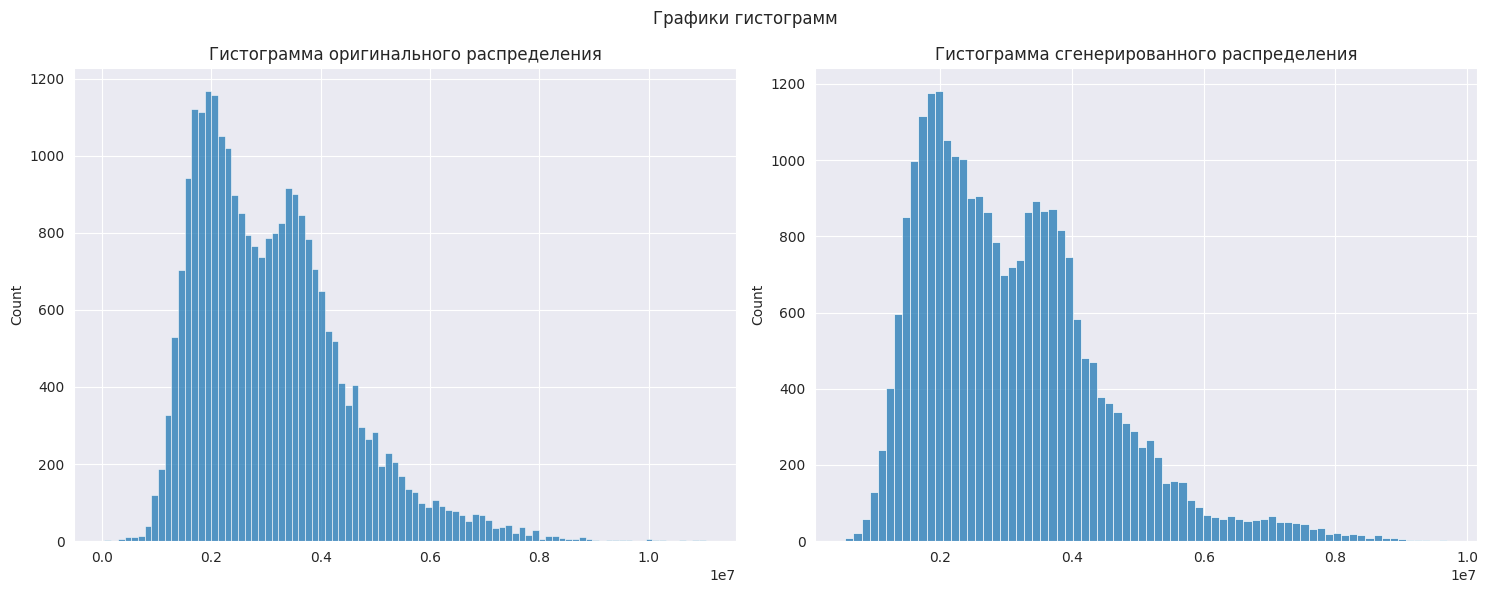

In [ ]:
nonzero, generated, gmm, args = get_fit_args(dtw_distances, 5)
plot_original_and_generated(nonzero, generated)

При помощи этой функции применим "квантилирование" к нашим данным для их перевода в равномерное рапределение

In [ ]:
def apply_pit(distances, nonzero, gmm, args):
    mask = ~np.eye(distances.shape[0], dtype=np.bool)
    distances[mask] = gmm.cdf(nonzero, *args)
    return distances

Есть пробитие!

In [ ]:
dtw_distances_adjusted = apply_pit(
    np.copy(dtw_distances), nonzero, gmm, args
)

А вот и второй способ достать признаки из ряда - с помощью объекта TSFreshFeatureExtractor. Он не извлекает один определённый тип характеристик, а вычисляет 777 разнородных числовых признаков, чтобы дать максимально полное описание временного ряда. Эти признаки можно разделить на несколько больших логических групп:

- Статистические и моментные - характеризуют распределение значений в ряду (среднее, медиана, дисперсия, асимметрия, эксцесс) и его энергетику (абсолютная энергия, RMS).

- Динамические и изменения - описывают, как именно меняется сигнал во времени (сумма и среднее абсолютных изменений, пересечения нуля, количество пиков).

- Корреляционные и частотные - оценивают "память" и периодические структуры в ряду (автокорреляция, спектральная плотность мощности, энтропия Фурье, коэффициенты авторегрессии).

- Сложность и нелинейность - измеряют степень хаотичности и структурной сложности сигнала (энтропия перестановок, сложность по Лемпелю-Зиву, вейвлет-коэффициенты).

- Трендовые и стационарности - определяют наличие долговременного тренда и стационарность процесса (линейный тренд, тест Дики-Фуллера)

In [ ]:
tsfresh_extractor = TSFreshFeatureExtractor(show_warnings=False)
tsfresh_actigraphy_features = tsfresh_extractor.fit_transform(actigraphy_pd)
tsfresh_actigraphy_features = StandardScaler().fit_transform(
    tsfresh_actigraphy_features
)

Feature Extraction: 100%|██████████| 162/162 [17:18<00:00,  6.41s/it]


Теперь посчитаем попарные евклидовые растояния между объектами (это пригодится в дальнейшем)

In [ ]:
tsfresh_euclidean_distances = euclidean_distances(
    tsfresh_actigraphy_features
)

Далее мы опять переведём наше распределение в равномерное с помощью 5 компонент Гауссовской смеси

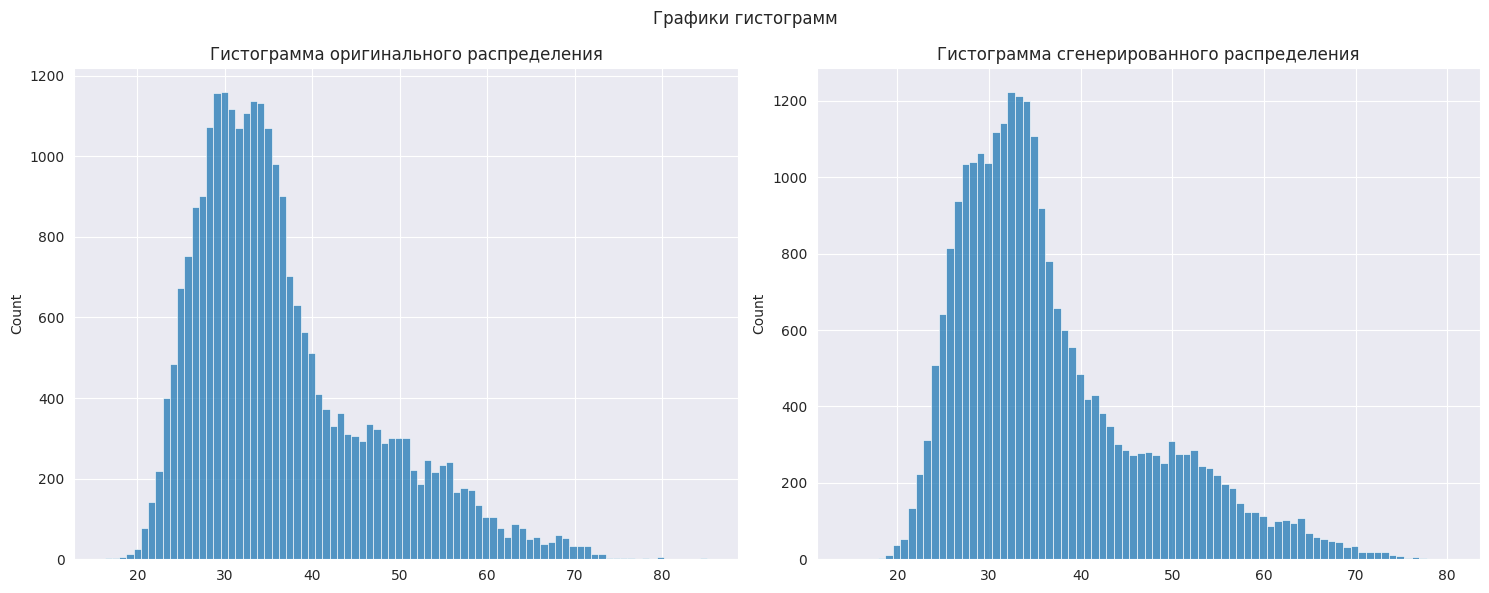

In [ ]:
nonzero, generated, gmm, args = get_fit_args(
    tsfresh_euclidean_distances, 5
)
plot_original_and_generated(nonzero, generated)

In [ ]:
tsfresh_euclidean_distances_adjusted = apply_pit(
    np.copy(tsfresh_euclidean_distances), nonzero, gmm, args
)

In [ ]:
sizes = np.array([len(value) for value in mental_illness.values()])
true_classes = np.array(list(
    chain.from_iterable([[i] * size for i, size in enumerate(sizes)])
))
true_labels = np.array(list(
    chain.from_iterable(
        [[key] * size for key, size in zip(mental_illness.keys(), sizes)]
    )
))

Теперь с помощью сжатия пространства до двумерного для двух разных полученных нами матриц посмотрим на визуализации точек в пространстве. Используемые инструменты:
- PCA
- KernelPCA
- UMAP

Эта функция нужна для обучения алгоритма сжатия пространства и его возвращения

In [ ]:
def get_mapper(cls, X, true_labels=true_labels, **params):
    mapper = cls(**params)
    class_name = mapper.__class__.__name__
    transformed = pd.DataFrame(
        mapper.fit_transform(X),
        columns=[f'{class_name}_{i}' for i in range(mapper.n_components)]
    )
    transformed['cluster'] = true_labels
    return transformed

Эта функция непосредственно нужна для отрисовки двумерного пространства

In [ ]:
def plot_projection(projection, title, palette='RdBu', width=1200, height=600):
  color_map = dict(zip(
      projection['cluster'].unique(),
      ['#F1948A', '#E74C3C', '#C0392B', '#78281F', '#3D0C0A']
  ))
  fig = px.scatter(
      projection,
      x=projection.columns[0],
      y=projection.columns[1],
      color='cluster',
      color_discrete_map=color_map,
      hover_data={
          'index': projection.index,
          'illness': projection['cluster']
      },
      width=width,
      height=height,
      title='Точечный график с цветами по кластерам'
  )
  fig.update_traces(
      hovertemplate=(
          '<b>Точка #%{customdata[0]}</b><br>x: %{x:.2f}<br>y: ' + \
          '%{y:.2f}<br>cluster: %{customdata[1]}<extra></extra>'
      )
  )
  fig.show()

Итак, начинаем отрисовывать для наших 2 матриц точечные диаграммы  использованием вышеназванных алгоритмов сжатия пространства

In [ ]:
pca_dtw_transformed = get_mapper(
    PCA,
    dtw_distances_adjusted,
    n_components=2,
    random_state=random_state
)

In [ ]:
plot_projection(pca_dtw_transformed, 'PCA')

In [ ]:
pca_tsfresh_transformed = get_mapper(
    PCA,
    tsfresh_actigraphy_features,
    n_components=2,
    random_state=random_state
)

In [ ]:
plot_projection(pca_tsfresh_transformed, 'PCA')

In [ ]:
kernel_pca_dtw_transformed = get_mapper(
    KernelPCA,
    dtw_distances_adjusted,
    n_components=2,
    kernel='rbf',
    random_state=random_state
)

In [ ]:
plot_projection(kernel_pca_dtw_transformed, 'KernelPCA')

In [ ]:
kernel_pca_tsfresh_transformed = get_mapper(
    KernelPCA,
    tsfresh_actigraphy_features,
    n_components=2,
    kernel='rbf',
    random_state=random_state
)

In [ ]:
plot_projection(kernel_pca_tsfresh_transformed, 'KernelPCA')

In [ ]:
umap_dtw_transformed = get_mapper(
    UMAP,
    dtw_distances_adjusted,
    n_components=2,
    n_neighbors=20,
    min_dist=0.5,
    random_state=random_state
)

In [ ]:
plot_projection(umap_dtw_transformed, 'UMAP')

In [ ]:
umap_tsfresh_transformed = get_mapper(
    UMAP,
    tsfresh_actigraphy_features,
    n_components=2,
    n_neighbors=20,
    min_dist=0.5,
    random_state=random_state
)

In [ ]:
plot_projection(umap_tsfresh_transformed, 'UMAP')

Общие выводы:
1) Для попарных расстояний DTW данные хорошо разделяются на 2 группы, а для признаков из TSFresh получается единое немного разреженное (так как данных мало) облако
2) При этом что в 2 группах, что в едином облаке прослеживается чёткая закономерность - в одной части находятся люди с СДВГ и тревожными расстройствами, а в другой - здоровые люди, люди с депрессией и шизофреники
3) Во второй части, где сосредоточены здоровые, депрессивные и шизофреники, есть область, где есть точки только здоровых людей, что может говорить о том, что депрессивные и шизофреники показывают заметно отличающиеся от здоровых людей результаты
4) На попарных расстояниях DTW есть один аномальный пациент с СДВГ, который либо был неправильно помечен (у него другой диагноз, либо же он вообще здоров), либо действительно демонтрирует аномальные показатели для своего диагноза

# Кластеризация

Итак, перейдём непосредственно к кластеризции и опишем работу нескольких используемых алгоритмов. Обозначим $\large{x_i = (x_i^1, x_i^2, ..., x_i^p)}$ - отдельный объект из выборки $\large{X}$ размера $\large{n}$, имеющий $\large{p}$ признаков

Я выбирал алгоритмы, которые удовлетворяют следующим 2 условиям:
1) Повзоляют задать изначальное число кластеров (так как у нас 5 классов)
2) Позволяют передать внутрь себя матрицу с заранее предпосчитанными попарными метриками сходства или различия (это условие опциональное, но такие алгоритмы обязательно должны быть использованы)

Начнём с самого известного алгоритма - K-Means. Алгоритм обучается следующим образом - сначала он находит $\large{k}$ центроидов $\large{C_k = (\mu_1, \mu_2, ..., \mu_k)}$. Как выбрать эти начальные центроиды? Есть 2 варианта:
- Случайнм образом
- Алгоритмом K-Means++ - первый центроид случайно, каждый следующий выбирается с вероятностью, пропорциональной квадрату расстояния до ближайшего уже выбранного центроида:
$$\large{P(x_i)=\frac{D(x_i)^2}{\sum_{j=1}^nD(x_j)^2} \ ,}$$
где $\large{D(x_i)=\underset{j=\overline{1,k}}{\min}\left|\left|x_i-\mu_j\right|\right|}$

Итоговая цель алгоритма - минимизировать внутрикластерную дисперсию (сумму квадратов расстояний от каждого окна до ближайшего центроида). Целевая функция выглядит так:
$$\large{J=\sum_{i=1}^{n}\underset{j=\overline{1,k}}{min}\left|\left|x_i-\mu_j\right|\right|_2^2}$$

Оптимизация происходит с помощью алгоритма Ллойда:
- Сначала каждому объекту сопоставляется кластер с юлижайшим центроидом:
$$\large{r_{ij}=\begin{cases}1, \ если \ j = \underset{j\in\overline{1,k}}{\left|\left|x_i-\mu_j\right|\right|_2^2} \ , \\ 0 \ , \ иначе\end{cases}}$$
- Центроиды пересчитываются как среднее арифметическое всех окон, назначенных в данный кластер:
$$\large{\mu_j=\frac{\sum_{i=1}^{T-m+1}r_{ij}x_i}{\sum_{i=1}^{T-m+1}r_{ij}}}$$

Критерии остановки алгоритмы следующие (отдельные варианты):
1) Центроиды перестают меняться (или меняются меньше порога $\large{\epsilon}$):
$$\large{\left|\left|\mu_j^{(t)} - \mu_j^{(t-1)}\right|\right| < \epsilon \  \forall j = \overline{1, k}}$$
2) Назначения кластеров не меняются:
$$\large{c_i^{(t)}=c_i^{(t-1)} \ \forall i = \overline{1, n}}$$
3) Изменение целевой функции мало:
$$\large{\left|J^{(t)} - J^{(t-1)}\right| < \epsilon}$$
4) Достигнуто максимальное число итераций



Следующий алгоритм - K-Medoids. Главное отличие в том, что здесь центроидом будет не некоторая абстрактная точка, а реальный объект из датасета

Первым делом опять выберем центроиды $\large{m_1, m_2, ..., m_k}$ так, чтобы расстояние от каждой центроида до других точек было минимально возможным

Двлее, если мы используем некоторую метрику $\large{d}$ для рассчёта расстояний между объектами (это не обязательно евклидово расстояние), то каждому объекту сопоставляем кластер, в который он попал:
$$\large{c_i=\underset{j=\overline{1,k}}{\arg \min} \ d(x_i, m_j)}$$

K-Medoids, если что, минимизирует следующую функцию:
$$\large{J=\sum_{j=1}^{k}\sum_{x_i \in C_j}d(x_i, m_j)}$$

Далее, место пересчета среднего, мы проверяем, можно ли уменьшить целевую функцию $\large{J}$, если поменять текущий медоид на какую-нибудь другую точку.
Для каждого текущего медоида $\large{m_j}$ и каждой немедоидной точки $\large{o_h}$ (кандидата на замену):
- Вычисляем изменение общей стоимости $\large{\Delta J}$, если мы заменим $\large{m_j}$ на $\large{o_h}$
- Если $\large{\Delta J < 0}$ (стоимость уменьшается), производим обмен: $\large{m_j \leftarrow o_h}$

Теперь рассмотрим то, как вычисляется изменение общей стоимости $\large{\Delta J}$. Когда мы меняем медоид $\large{m_j}$ на кандидата $\large{o_h}$, каждая точка $\large{x_i}$ в датасете может изменить свое поведение. Для каждой точки $\large{x_i}$ считаем вклад в изменение стоимости $\large{C_i}$:
1) Если $\large{x_i}$ сейчас принадлежит кластеру $\large{m_j}$:
   - Найдём второй ближайший медоид $\large{m_{2nd}}$ для $\large{x_i}$
   - Если $\large{d(x_i, o_h) \geq d(x_i, m_{2nd})}$, точка переходит к $\large{m_{2nd}}$

     $$\large{C_i = d(x_i, m_{2nd}) - d(x_i, o_h)}$$

   - Если $\large{d(x_i, o_h) < d(x_i, m_{2nd})}$, точка останется с новым медоидом $\large{o_h}$

     $$\large{C_i = d(x_i, o_h) - d(x_i, m_j)}$$  

2) Если $\large{x_i}$ принадлежит другому кластеру (медоиду $\large{m_l}$, где $\large{l \neq j}$)
   - Если $\large{d(x_i, o_h) < d(x_i, m_l)}$, точка перейдёт к $\large{o_h}$

     $$\large{C_i = d(x_i, o_h) - d(x_i, m_l)}$$

   - Иначе точка останется на месте

     $$\large{C_i=0}$$

Общее изменение стоимости $\large{\Delta J = \sum_{i=1}^n C_i}$. Если $\large{\Delta J < 0}$, то обмен выгоден

Критерии остановки - либо если целевая функция $\large{J}$ перестала уменьщаться, либо если было достигнуто максимальное количество итераций

В отличие от K-Means, K-Medoids позволяет передать матрицу препосчтанных расстояний заранее

Далее разберём иерархическую аггломеративную кластеризацию. Идея алгорима очень простая:
1) Каждая точка - отдельный кластер (всего есть $\large{n} точек$)
2) Объединяем 2 наиболее похожих кластера между собой и объединяем их в один. Соответственно после этого действия пересчитываются значения похожести этого нового кластера с другими
3) Пункт 2 повторяется до  тех пор, пока не будет достигнуто заранее заданное число кластеров

Теперь вопрос в том, как вычислять сходство кластеров друг с другом (а точнее здесь будет сказать, расстояние от одного кластера до другого). Самым эффективным считается метод Уорда, который работает с центроидами кластеров:
$$\large{\Delta(A, B)=\frac{\left|A\right|\cdot\left|B\right|}{\left|A\right|+\left|B\right|}\left|\left|\mu_A-\mu_B\right|\right|_2^2}$$

Уникальная фича иерархической кластеризации — это дендрограмма (дерево).
Она показывает, какие кластеры слились, на каком "расстоянии" (высоте) это произошло и в каком порядке.
Если провести горизонтальную линию через дендрограмму, то точки пересечения с ветвями покажут кластеризацию для данного числа $\large{k}$. Это позволяет не задавать $\large{k}$ заранее, а выбрать его постфактум, глядя на графиr (хотя в нашей задаче конечно число кластеров известно заранее)

Сам алгоритм кластеризации хорошо подходит для малых и средних выборок (до 5000 объектов), поэтому нам с нашими 162 рядами беспокоиться на о чем

Аггломеративная кластеризщация, также как и K-Medoids, позволяет заранее передать матрицу препосчтанных расстояний

 ̶У̶ж̶е̶ ̶в̶и̶д̶е̶н̶ ̶с̶в̶е̶т̶ ̶в̶ ̶к̶о̶н̶ц̶е̶ ̶т̶у̶н̶н̶е̶л̶я̶!̶ Далее разберём такой алгоритм как спектральная кластеризация

Вместо того чтобы смотреть на точки как на объекты в пространстве, спектральная кластеризация представляет их как вершины графа:
- Если две точки похожи, между ними есть «тяжелое» ребро
- Если не похожи — ребра нет (или оно очень легкое)

Задача алгоритма заключается в том, чтобы разрезать этот граф на $\large{K}$
кусков (кластеров) так, чтобы разорвать как можно меньше «тяжелых» связей внутри кластеров и как можно больше «легких» связей между ними

Итак, сначала строим матрицу сходства $\large{W}$, где $\large{W_ij}$ показывает, насколько точка $\large{i}$ похожа на точку $\large{j}$. Обычно используется Гауссовское ядро:
$$\large{W_{ij}=e^{-\frac{\left|\left|x_i - x_j\right|\right|^2}{\sigma^2}} \ ,}$$
если точки близко, то $\large{W_{ij} \approx 1}$, если же далеко, то $\large{W_{ij} \approx 0}$

Далее считаем матрицу степеней $\large{D}$ - диагональная матрица, где на диагонали стоят суммы весов ребер для каждой вершины:
$$\large{D_{ii}=\sum_{j=1}^n W_{ij} \ ,}$$
затем вычисляем Лапласиан $\large{L}$:
$$\large{L = D - W}$$

Затем находим собственные векторы Лапласиана и оставляет только первые $\large{k}$, соответствующие наибольшим по модулю собственным значениям и получаем матрицу $\large{U}$ размерностью $\large{n \times k}$. Интерсный момент заключается в том, что это число $\large{k}$ равняется исходному числу желаемых кластеров

Ну а затем запускаем на этой матрице U обычный K-Means

Алгоритм меленный, да, зато способеннаходить кластеры самой извращённой формы

Последний алгоритм - Гауссовская смесь. Я уже расписывал, что там для каждой точки рассчитывается вероятность принадлежности к определённой компоненте (в нашем случае компоненту рассматриваем как кластер). И итоговый кластер соответствует максимальной такой вероятности по всем кластерам для данного объекта

 Ещё хочется отметить, что так как номера кластеров ссами по себе смысла не имеют, то с использованием венгерского алгоритма и исходных меток номера кластеров перенумеровывается, чтобы как можно более точно соответствовать исходным классам

In [ ]:
def renumber_labels(true_classes, local_preds):
    cm = confusion_matrix(true_classes, local_preds)
    rows, cols = linear_sum_assignment(-cm)
    mapping = dict(zip(rows, cols))
    return np.vectorize(mapping.get)(local_preds)

def apply_clustering(
    X,
    true_classes,
    models,
    kernel=None,
    distances_function=None
):
    labels, names = [], []
    for model in models:
        if not isinstance(model, Iterable):
            features = X
            if isinstance(model, (
                SpectralClustering,
                ConstrainedSpectralClustering
            )) and \
                model.affinity[:11] == 'precomputed':
                if kernel is None:
                    features = 1 - X
                else:
                    features = kernel(X)
            local_preds = model.fit_predict(features)
            local_preds = renumber_labels(true_classes, local_preds)
            labels.append(local_preds)
            names.append(model.__class__.__name__)
        else:
            distances = X
            if distances_function is not None:
                distances = distances_function(X)
            Z = model[0](y=distances)
            local_preds = model[1](Z=Z) - 1
            local_preds = renumber_labels(true_classes, local_preds)
            labels.append(local_preds)
            names.append(' + '.join([
                element.func.__name__ for element in model
            ]))
    return dict(zip(names, labels))

Далее, качество кластеризации нужно как-то измерить. Какие-то метрики будут направлены на качество разделения данных на кластеры (здесь необходимо иметь эти самые исходные данные), а какие-то на соответствие найденных кластеров исходным классам

Разберём первый набор этих метрик. И первенец здесь - коэффициент силуэта.
Диапазон значения - $\large{[-1; 1]}$, чем больше, тем лучше. Коэффициент показывает, насколько точки похожи на свои кластеры по сравнению с другими кластерами

Коэффициент для каждой отлельной точки вычисляется следующим образом - сначала высчитывается компактность (среднее расстояние до точек своего кластера):
$$\large{a(i)=\frac{1}{\left|C_i\right|-1}\sum_{j \in C_i, j \neq i} d(i, j) \ ,}$$
где $\large{d}$ - некая метрика расстояния (по умолчанию - евклидово расстояние)

Далее вычисляется разделимость (минимальное среднее расстояние до точек ближайшего чужого кластера):
$$\large{b(i)=\underset{j \neq C_i}{\min}\frac{1}{\left|C_i\right|}\sum_{l \in C_j} d(i, l) \ , \ j=\overline{1, k}}$$

Ну и, собственно, сам коэффициент силуэта:
$$\large{s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}}$$

Для всех данных коэффициент вычисляется так:
$$\large{S=\frac{1}{n}\sum_{i=1}^n s(i)}$$

Далее следует индекс Калински-Харабаша. Диапазон значения от нуля до бесконечности, чем больше, тем лучше. Индекс показывает отношение межкластерной дисперсии к внутрикластерной. Хорошая кластеризация — когда кластеры плотные (малая внутрикластерная дисперсия) и хорошо разделены (большая межкластерная дисперсия)

Формула индекса представлена ниже:
$$\large{CH=\frac{B}{W}\cdot\frac{n - k}{k - 1} \ ,}$$
где:
- $\large{k}$ - число кластеров
- $\large{B}$ - межкластерная дисперсия, вычисляющаяся по следующей формуле:
$$\large{B=\sum_{j=1}^kn_j\left|\left|c_j-\mu\right|\right|^2}$$
- $\large{W}$ - внутрикластерная дисперсия, вычисляющаяся по следующей формуле:
$$\large{\sum_{j=1}^k\sum_{x\in C_j}\left|\left|x-c_j\right|\right|^2}$$

Ну и замыкает этот триумвират индекс Дэвиса-Болдуина. Диапазон значения от нуля до бесконечности, чем меньше, тем лучше. Индекс показывает среднее максимальное сходство между каждым кластером и его наиболее похожим соседом. Учитывает как плотность кластеров, так и расстояние между ними. Меньшее значение означает лучшую кластеризацию

Вычисляется так:
$$\large{DB=\frac{1}{k}\sum_{j=1}^k\underset{i=\overline{1, k}, i \neq j}{\max}R_{ij} \ ,}$$
где $\large{R_{ij}}$ - мера сходства между кластерами $\large{i}$ и $\large{j}$:
$$\large{R_{ij}=\frac{s_i + s_j}{d(i, j)} \ ,}$$
где:
- $\large{s_i}$ - плотность кластера (средний разброс точек):
$$\large{s_i=\frac{1}{\left|C_i\right|}\sum_{x\in C_i}\left|\left|x-c_i\right|\right|}$$
- $\large{d(i, j)}$ - разделимость (расстояние между центроидами кластеров)


Так, теперь перекючимся на те метрики, где измеряется именно согласовааность кластеров и исходных классов. Заранее введём некоторые обозначения:
- $\large{U}$ - истинная разметка
- $\large{V}$ - полученная кластеризация
- $\large{n_{ij}}$ - число объектов в истинном классе $\large{i}$ и предсказанном кластере $\large{j}$
- $\large{a_i=\sum_{j}n_{ij}}$ - размер истинного класса $\large{i}$
- $\large{b_j=\sum_{i}n_{ij}}$ - размер предсказанного кластера $\large{j}$

Первая метрика - Adjusted mutual information (AMI, переводится как скорректированная взаимная информация). Диапазон значений от минус бесконечности до 1. Метрика измеряет количество информации, которое предсказанная кластеризация дает об истинной. Поправка на случайность гарантирует, что случайные разбиения будут иметь оценку около 0, независимо от числа кластеров и объектов

Итак, пусть верны следующие обозначения:
- Энтропия истинной разметки
$$\large{H(U)=-\sum_{i=1}^{\left|U\right|}\frac{a_i}{n}\log\left(\frac{a_i}{n}\right)}$$
- Взаимная информация
$$\large{MI(U,V)=\sum_{i=1}^{\left|U\right|}\sum_{j=1}^{\left|V\right|}\frac{n_{ij}}{n}\log\left(\frac{n\cdot n_{ij}}{a_i\cdot b_j}\right)}$$

Тогда занчение метрики вычисляется следующим образом:
$$\large{AMI=\frac{MI(U, V)-\mathbb{E}[MI]}{\max(H(U), H(V))-\mathbb{E}[MI]} \ ,}$$
где $\large{\mathbb{E}[MI]}$ - математическое ожидание взаимной информации при случайной метрике

Уже приветливо машет нам ручкой Adjusted Rand index (ARI, переводится как скорректированный индекс Рэнда). Диапазон от -1 до 1. Чем выше, тем лучше. Индекс оценивает сходство двух разбиений на основе попарного сравнения объектов, подсчитывая, насколько часто пары объектов, которые находятся в одном классе, оказываются в одном кластере (и наоборот)

Формула громоздкая и может сломать мозг:
$$\large{ARI=\frac{\sum_{i,j}\begin{pmatrix}n_{ij} \\ 2\end{pmatrix} - \frac{\sum_i\begin{pmatrix}a_i \\ 2\end{pmatrix}\cdot\sum_j\begin{pmatrix}b_j \\ 2\end{pmatrix}}{\begin{pmatrix}n \\ 2\end{pmatrix}}}{\frac{1}{2}\left[\sum_i\begin{pmatrix}a_i \\ 2\end{pmatrix}+\sum_j\begin{pmatrix}b_j \\ 2\end{pmatrix}\right] - \frac{\sum_i\begin{pmatrix}a_i \\ 2\end{pmatrix}\cdot\sum_j\begin{pmatrix}b_j \\ 2\end{pmatrix}}{\begin{pmatrix}n \\ 2\end{pmatrix}}}}$$

Третья метрика - homogeneity (однородность). Диапазон значений от 0 до 1 и чем выше, тем лучше. Метрика оценивает "чистоту" кластеров и штрафует за смешивание разных классов внутри одного кластера, так как каждый кластер должен содержать объекты только одного истинного класса

Вычисляется она следующим образом:
$$\large{h=1-\frac{H(U|V)}{H(U)} \ ,}$$
где $\large{H(U|V)}$ - условная энтропия истинной разметки при известной кластеризации:
$$\large{H(U|V)=-\sum_{i=1}^{\left|U\right|}\sum_{j=1}^{\left|V\right|}\frac{n_{ij}}{n}\log\left(\frac{n\cdot n_{ij}}{b_j}\right)}$$

У нас покер, дамы и господа! Четвёртая метрика - completeness (полнота). Диапазон значений от 0 до 1 и чем выше, тем лучше. Метрика оценивает, насколько полно классы собраны в кластеры и штрафует за разбивание одного класса на несколько кластеров, так как все объекты одного истинного класса должны попасть в один кластер

$$\large{h=1-\frac{H(V|U)}{H(U)} \ ,}$$
где $\large{H(V|U)}$ - условная энтропия кластеризации при известной истинной разметке:
$$\large{H(V|U)=-\sum_{i=1}^{\left|U\right|}\sum_{j=1}^{\left|V\right|}\frac{n_{ij}}{n}\log\left(\frac{n\cdot n_{ij}}{a_i}\right)}$$

Ну и пятая (наконец-то!) метрика - V-measure. Диапазон от 0 до 1 и чем выше, тем лучше. По ути своей, метрика представляет собой гармоническое среднее Homogeneity и Completeness. Позволяет найти баланс между "чистотой" кластеров и "полнотой" сбора классов, когда одно противоречит другому (например, создание кластера из одного объекта дает идеальную Homogeneity, но ужасную Completeness)

Вот формула:
$$\large{\nu=2\cdot\frac{h\cdot c}{h+c}}$$

In [ ]:
def show_metrics(true_classes, dictionary, X=None):
    metrics = None
    for local_name, local_preds in dictionary.items():
        dictionary = {
            'AMI': [adjusted_mutual_info_score(true_classes, local_preds)],
            'ARI': [adjusted_rand_score(true_classes, local_preds)],
            'Completeness': [completeness_score(true_classes, local_preds)],
            'Homogeneity': [homogeneity_score(true_classes, local_preds)],
            'V-measure': [v_measure_score(true_classes, local_preds)],
        }
        if X is not None:
            dictionary['Silhouette'] = [silhouette_score(X, local_preds)]
            dictionary['Calinski-Harabasz'] = [
                calinski_harabasz_score(X, local_preds)
            ]
            dictionary['Davies-Bouldin'] = [
                davies_bouldin_score(X, local_preds)
            ]
        metrics = pd.concat([
            metrics,
            pd.DataFrame(dictionary, index=[local_name])
        ])
    return metrics

Ну и в дополнение было бы неплохо и на размеры кластеров посмотреть, а то значения метрик могут быть обманчивыми

In [ ]:
def get_cluster_sizes(dictionary):
    sizes = pd.DataFrame({})
    for key in dictionary.keys():
        sizes = pd.concat([
            sizes,
            pd.DataFrame(
                dict(Counter(dictionary[key])),
                index=[key]
            )
        ])
    sizes = sizes[sorted(sizes.columns)]
    return sizes

## Кластеризация без ограничений

### Признаки, полученные из TSFresh

In [ ]:
%%time
set_random_seed()

tsfresh_dictionary = apply_clustering(
    tsfresh_actigraphy_features,
    true_classes,
    [
        KMeans(n_clusters=5, random_state=random_state),
        KMedoids(
            n_clusters=5,
            metric='euclidean',
            random_state=random_state
        ),
        AgglomerativeClustering(n_clusters=5),
        SpectralClustering(
            n_clusters=5,
            affinity='nearest_neighbors',
            random_state=random_state
        ),
        GaussianMixture(n_components=5, random_state=random_state)
    ]
)

CPU times: user 3.33 s, sys: 26.3 ms, total: 3.35 s
Wall time: 2.33 s


Итак, получим значения метрик для кластеризации на признаках из TSFresh

In [ ]:
tsfresh_metrics = show_metrics(true_classes, tsfresh_dictionary, tsfresh_actigraphy_features)
tsfresh_metrics

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeans,0.303638,0.224608,0.383827,0.291213,0.331167,0.051872,10.550647,2.374291
KMedoids,0.422769,0.312840,0.454216,0.432140,0.442903,0.004617,9.885084,2.959417
AgglomerativeClustering,0.430944,0.348277,0.511507,0.406968,0.453288,0.041779,10.421284,2.507788
SpectralClustering,0.329171,0.217911,0.350213,0.352515,0.351360,-0.019184,8.387714,3.385892
GaussianMixture,0.303638,0.224608,0.383827,0.291213,0.331167,0.051872,10.550647,2.374291


In [ ]:
get_cluster_sizes(tsfresh_dictionary)

,0,1,2,3,4
KMeans,68,3,26,4,61
KMedoids,8,53,34,33,34
AgglomerativeClustering,50,30,6,4,72
SpectralClustering,22,37,26,33,44
GaussianMixture,68,3,26,4,61


Выводы:
- В среднем наилучший по метрикам алгоритм - это аггломеративная кластеризация
- По адекватности размера кластеров лидером является спектральная кластеризация
- У всех моделей очень слабый коэффициент силуэта, что может говорить о том, что точки слабо похожи на своих "собратьев по кластеру"

### Попарные растояния DTW

Для спектральной кластеризации можо использовать различные ядра, чтобы значения матрицы сходства лежали в диапазоне от 0 до 1. Для уже посчитанных расстояний $\large{d}$ ядра выглядят следующим образом:
- RBF-ядро - $\large{k(d)=e^{-frac{d^2}{2\sigma^2}}}$
- Ядро Лапаласа - $\large{k(d)=e^{-frac{d}{\sigma}}}$
- Полиномиальное ядро - $\large{k(d)=\left(\frac{1}{1 + D} + C\right)^{-1}}$
- Ядро Коши - $\large{k(d)=\frac{1}{1 + \left(\frac{d}{\sigma}\right)^2}}$
- Рациональное квадратичное ядро - $\large{k(d)=\left(1 + \frac{d^2}{2\alpha\sigma^2}\right)^{-\alpha}}$
- Волновое ядро - $\large{k(d)=\frac{\theta}{d}\cdot\sin\left(\frac{\theta}{d}\right)}$

In [ ]:
def rbf_kernel(D, sigma=None):
    if sigma is None:
        sigma = np.median(D[D > 0])
    return np.exp(-np.square(D) / (2 * sigma ** 2))

def laplacian_kernel(D, sigma=None):
    if sigma is None:
        sigma = np.median(D[D > 0])
    return np.exp(-D / sigma)

def poly_kernel(D, degree=3, c=1):
    S = 1 / (1 + D)
    return (S + c) ** degree

def cauchy_kernel(D, sigma=None):
    if sigma is None:
        sigma = np.median(D[D > 0])
    return 1 / (1 + np.square(D) / sigma ** 2)

def rational_quadratic_kernel(D, alpha=1.0, sigma=None):
    if sigma is None:
        sigma = np.median(D[D > 0])
    return (1 + np.square(D) / (2 * alpha * sigma ** 2)) ** (-alpha)

def wave_kernel(D, theta=1.0):
    K = np.where(D == 0, 1.0, (theta / D) * np.sin(D / theta))
    return K

Теперь получим значения метрик для кластеризации на попарных расстояних DTW

In [ ]:
%%time
set_random_seed()

dtw_precomputed_dictionary = apply_clustering(
    dtw_distances_adjusted,
    true_classes,
    [
        [
            partial(linkage, method='ward'),
            partial(fcluster, t=5, criterion='maxclust')
        ],
        SpectralClustering(
            n_clusters=5,
            affinity='precomputed',
            random_state=random_state
        )
    ],
    kernel=rational_quadratic_kernel,
    distances_function=squareform
)

CPU times: user 70.9 ms, sys: 827 µs, total: 71.7 ms
Wall time: 41.6 ms


In [ ]:
dtw_precomputed_metrics = show_metrics(
    true_classes,
    dtw_precomputed_dictionary,
    dtw_distances_adjusted
)
dtw_precomputed_metrics

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
linkage + fcluster,0.534312,0.443512,0.609768,0.504300,0.552042,0.328830,133.992892,1.624046
SpectralClustering,0.483695,0.397789,0.535197,0.473483,0.502452,0.230945,106.769084,1.856484


In [ ]:
get_cluster_sizes(dtw_precomputed_dictionary)

,0,1,2,3,4
linkage + fcluster,20,14,32,86,10
SpectralClustering,77,17,12,30,26


Выводы:
- По всем метрикам аггломеративная кластеризация оказалась лучше спектральной
- Однако видим, что у аггломеративной кластеризации большая часть данных находится в одном из кластеров, что не есть хорошо. У спектральной кластеризации тоже есть такое, однако там размер большого кластера всё же не превышает суммарно все остальные
- Значения "метрик данных" (коэффициент силуэта, индекс Калински-Харабаша, индекс Дэвиса-Болдуина) в разы лучше, чем у предыдущей кластеризации, а значения метрик качества сопоставления исходных классов и полученных кластеров как минимум не уступают

### Попарные расстояния DTW как набор признаков

Что нам мешает рассмотреть матрицу попарных расстояний DWT как матрицу признаков? Да ничего не мешает. Ну да, так вышло, что количество признаков равняется количетву объектов, ну и что с того?

In [ ]:
%%time
set_random_seed()

dtw_features_dictionary = apply_clustering(
    dtw_distances_adjusted,
    true_classes,
    [
        KMeans(n_clusters=5, random_state=random_state),
        KMedoids(
            n_clusters=5,
            metric='euclidean',
            random_state=random_state
        ),
        AgglomerativeClustering(n_clusters=5),
        SpectralClustering(
            n_clusters=5,
            n_neighbors=10,
            affinity='nearest_neighbors',
            random_state=random_state
        ),
        GaussianMixture(n_components=5, random_state=random_state)
    ]
)

CPU times: user 229 ms, sys: 784 µs, total: 230 ms
Wall time: 121 ms


In [ ]:
dtw_features_metrics = show_metrics(
    true_classes,
    dtw_features_dictionary,
    dtw_distances_adjusted
)
dtw_features_metrics

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeans,0.481670,0.340632,0.501795,0.496403,0.499085,0.356909,199.890980,0.945892
KMedoids,0.481310,0.326039,0.500956,0.496504,0.498720,0.336399,210.250507,1.031924
AgglomerativeClustering,0.495585,0.341124,0.526658,0.500303,0.513142,0.304323,195.112153,0.992495
SpectralClustering,0.516077,0.379186,0.556933,0.511619,0.533316,0.364404,206.471039,0.891423
GaussianMixture,0.481670,0.340632,0.501795,0.496403,0.499085,0.356909,199.890980,0.945892


In [ ]:
get_cluster_sizes(dtw_features_dictionary)

,0,1,2,3,4
KMeans,35,48,36,27,16
KMedoids,44,16,26,40,36
AgglomerativeClustering,10,40,28,56,28
SpectralClustering,10,30,38,19,65
GaussianMixture,35,48,36,27,16


Выводы:
- По метрикам в среднем лучшим алгоритмом оказалась пектральная кластеризация
- По размерам кластеров даже "поругать" некого особо - не выделяется один гигантский кластер или куча мелких
- Значения первых 5 метрик чуть ниже, чем в предыдущем случае, а вот последних трёх - ещё улучшились

То есть рассмотрение матрицы попарных расстояний DTW именно как набора признаков пока показало наилучший результат

## Ансамблевая кластеризация

Всего будет рассмотрено 3 метода ансамблевой кластеризации и первый из них - обычное мажоритарное голосование. Так как мы перенумеровали кластеры, то оно теперь имеет смысль. Голосование будет взвешенным и в качестве весов будут выступать значени метрики ARI

In [ ]:
ensemble_dictionary = {}

In [ ]:
ari = []
for dictionary in (
    tsfresh_dictionary,
    dtw_precomputed_dictionary,
    dtw_features_dictionary
):
    for local_name, local_preds in dictionary.items():
        ari.append(adjusted_rand_score(true_classes, local_preds))
ari = np.array(ari)
ari /= ari.sum()

In [ ]:
stacked = np.vstack([
    list(dictionary.values()) for dictionary in [
        tsfresh_dictionary,
        dtw_precomputed_dictionary,
        dtw_features_dictionary
    ]
])
weights = np.vstack(
    [np.sum((stacked == cluster) * ari[:, None], axis=0) \
    for cluster in np.unique(stacked)]
)
ensemble_dictionary['Voting'] = np.argmax(weights, axis=0)

Следующим делом построим матрицу коассоциаций - для каждой пары обхектов для разных кластеризаций считаем, сколько раз они попали в один и тот же кластер, а потом делим на итоговое число проведённых кластеризаций

In [ ]:
def build_coassotiation_matrix(n, *dictionaries):
    m = 0
    coassotiation_matrix = np.zeros((n, n))
    for dictionary in dictionaries:
        for local_preds in dictionary.values():
            m += 1
            for i in range(n):
                for j in range(i, n):
                    if local_preds[i] == local_preds[j]:
                        coassotiation_matrix[i][j] += 1
                        if i != j:
                            coassotiation_matrix[j][i] += 1
    coassotiation_matrix /= m
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            edges.append([i, j, coassotiation_matrix[i][j].item()])
    edges = sorted(edges, key=lambda e: -e[-1])
    return coassotiation_matrix, edges

In [ ]:
coassotiation_matrix, edges = build_coassotiation_matrix(
    len(true_classes),
    tsfresh_dictionary,
    dtw_precomputed_dictionary,
    dtw_features_dictionary
)

Второй способ ансамблевой кластеризации - с использованием структуры данных под названием "система непересекающихся множеств" (СНМ) рассматриваем матрицу коассоциаций как граф. Значение в ячейке в $\large{i}$-ой строке и в $\large{j}$-ом столбце рассматриваем как вес ребра между двумя вершинами $\large{i}$ и $\large{j}$

Ну а далее просто сортируем рёбра по убыванию и пытаемся соединить 2 кластера в один (изначально каждая отдельная точка - кластер) до тех пор, пока не образуется заданное изначальное число кластеров

In [ ]:
def find_ancestor(u, ancestors):
    if u == ancestors[u]:
        return u
    ancestors[u] = find_ancestor(ancestors[u], ancestors)
    return ancestors[u]

def union(u, v, ancestors, sizes, n_clusters):
    u, v = find_ancestor(u, ancestors), find_ancestor(v, ancestors)
    if u != v:
        n_clusters -= 1
        if sizes[u] < sizes[v]:
            u, v = v, u
        sizes[u] += sizes[v]
        ancestors[v] = u
    return n_clusters

def apply_dsu(
    n,
    edges,
    n_total_clusters=np.unique(true_labels).shape[0],
    max_weight=None
):
    n_clusters = n
    ancestors, sizes = np.arange(n), np.ones(n).astype(int)
    for i, j, w in edges:
        if max_weight is not None and w < max_weight:
            break
        n_clusters = union(i, j, ancestors, sizes, n_clusters)
        if n_total_clusters is not None and n_clusters == n_total_clusters:
            break
    for u in range(len(ancestors)):
        ancestors[u] = find_ancestor(u, ancestors)
    unique = np.unique(ancestors)
    mapping = dict(zip(unique, np.arange(unique.shape[0])))
    preds = np.vectorize(mapping.get)(ancestors)
    return preds

In [ ]:
ensemble_dictionary['DSU'] = n_clusters_preds = apply_dsu(
    len(true_labels),
    edges
)

Третий способ - просто подать матрицу коассоциаций на вход спектральной кластеризации

In [ ]:
spectral = SpectralClustering(
    n_clusters=5,
    affinity='precomputed',
    random_state=random_state
)
ensemble_dictionary['Spectral'] = spectral.fit_predict(coassotiation_matrix)

In [ ]:
show_metrics(true_classes, ensemble_dictionary)

,AMI,ARI,Completeness,Homogeneity,V-measure
Voting,0.169504,0.103094,0.208060,0.191272,0.199313
DSU,0.585968,0.415602,0.824115,0.473858,0.601728
Spectral,0.502529,0.332318,0.528063,0.511425,0.519611


In [ ]:
get_cluster_sizes(ensemble_dictionary)

,0,1,2,3,4
Voting,50,14,9,48,41
DSU,1,84,7,69,1
Spectral,11,44,25,42,40


Выводы:
- Алгоритм DSU оказался лучший по метрикам, но вот с размерами кластеров там беда - 2 гиганта, 1 мелкий и 2 кластера-одиночки. Такую кластеризацию с учётом размеров исходных классов никак не получится назвать хорошей
- Мажоритарное голосование оказалоь наихудшим по метрикам реди вообще всех проведённых кластеризаций
- Спектральная кластеризация мо метрикам занимает 2 место, и имеет более или менее адекватные размеры кластеров. Лучшим анамблевым методом я бы назвал именно её

## Взвешенная кластеризация

Взвешенная кластеризация - это просто взвешенное суммирование матриц попарных расстояний (DTW и евклидова для признаков из TSFresh). Плю добавится ещё матрица расстояний между пользователями как людьми с различными признаками

Сначала достанем персональную информацию о пациентах

In [ ]:
directory = '/content'
info_files = sorted([
    file for file in os.listdir(directory) \
     if os.path.isfile(os.path.join(directory, file)) \
     and file.endswith('-info.csv')
])

personal_info = []
for file in info_files:
    personal_info.append(pd.read_csv(file)[['age', 'gender']])
personal_info = pd.concat(personal_info)

Теперь немного подправим значения признаков - для возраста, например, будет 4 категории - молодёжь (до 30 лет), молодые люди (30-39 лет), зрелые люди (40-49 лет) и предпенсионеры и пенсионеры (от 50 лет и старше)

In [ ]:
personal_info['gender'] = personal_info['gender'].replace({1: 0, 2: 1})
personal_info['age'] = personal_info['age'].replace({
    '17-29': 0,
    '20-24': 0,
    '25-29': 0,
    '30-34': 1,
    '30-39': 1,
    '35-39': 1,
    '40-44': 2,
    '40-49': 2,
    '45-49': 2,
    '50-54': 3,
    '50-67': 3,
    '55-59': 3,
    '55-60': 3,
    '60-64': 3,
    '65-69': 3
}).astype(int)

Теперь посчитаем евклидовы расстояния между 2 признаками и переведём распределерие этих растояний опять в стандартное равномерное путём деления на максимальное полученное расстояние

In [ ]:
personal_info_euclidean_distances = euclidean_distances(personal_info)
personal_info_euclidean_distances_adjusted = \
personal_info_euclidean_distances / personal_info_euclidean_distances.max()

С помощью этой функции можно составить взвешенную комбинацию из различных матриц

In [ ]:
def get_weighted_matrix(matrices, weights, normalize=True):
    if len(matrices) != len(weights):
        print(
            'Длины списков с расстояниями и весами должны быть одинаковой длины'
        )
        return
    weights = np.array(weights)
    weights /= weights.sum()
    result = np.vstack([
        (matrix * weight)[None, ...] for \
        matrix, weight in zip(matrices, weights)
    ]).sum(axis=0)
    if normalize:
        result = (result + result.T) / 2
    return result

Получим взвешенную матрицу с некоторыми из головы взятыми коэффициентами

In [ ]:
weighted_distances = get_weighted_matrix(
    [
        dtw_distances_adjusted,
        tsfresh_euclidean_distances_adjusted,
        personal_info_euclidean_distances_adjusted
    ],
    [0.6, 0.3, 0.1]
)

Библиотека constrained-linkage предоставляет замечательный инструмент в виде определения матрицы ограничений:
- Если в ячейке в $\large{i}$-ой строке и в $\large{j}$-ом столбце стоит отрицательное число, то объекты под номерами $\large{i}$ и $\large{j}$ должны оказаться в одном кластере. Чем больше по модулю число, тем сильнее штраф
- Если в ячейке в $\large{i}$-ой строке и в $\large{j}$-ом столбце стоит положительное число, то объекты под номерами $\large{i}$ и $\large{j}$ не должны оказаться в одном кластере. Чем больше число, тем сильнее штраф
- Если в ячейке в $\large{i}$-ой строке и в $\large{j}$-ом столбце стоит 0, то никаких ограничений на совместное ̶п̶р̶о̶з̶я̶б̶а̶н̶и̶е̶  пребывание объектов под номерами $\large{i}$ и $\large{j}$ в одном кластере не накладывается

Строится матрица ограниченйи будет на основе уже посчитанной матрицы коассоциаций:
- Если число в ячейке меньше 0.2, то объекты не должны оказаться в одном кластере и значение в матрице ограничений будет равно разнице единицы и числа в матрице коассоциаций
- Если число в ячейке больше 0.7, то объекты должны оказаться в одном кластере и значение в матрице ограничений будет равно минус числу в матрице коассоциаций

In [ ]:
def get_constraint_matrix(
    coassotion_matrix,
    cannot_threshold=0.2,
    must_threshold=0.7
):
    constraint_matrix = np.zeros_like(coassotion_matrix)
    must_mask = coassotion_matrix > must_threshold
    cannot_mask = coassotion_matrix < cannot_threshold
    constraint_matrix[must_mask] = -coassotiation_matrix[must_mask]
    constraint_matrix[cannot_mask] = 1 - coassotiation_matrix[cannot_mask]
    return constraint_matrix

In [ ]:
constraint_matrix = get_constraint_matrix(coassotiation_matrix)

### Попарное сходство

Поехали!

In [ ]:
%%time
set_random_seed()

weighted_precomputed_dictionary = apply_clustering(
    weighted_distances,
    true_classes,
    [
        [
            partial(linkage, method='ward'),
            partial(fcluster, t=5, criterion='maxclust')
        ],
        [
            partial(
                constrained_linkage,
                method='ward',
                constraint_matrix=constraint_matrix,
                max_penalty_weight=1,
                normalize_distances=False
            ),
            partial(fcluster, t=5, criterion='maxclust')
        ],
        SpectralClustering(
            n_clusters=5,
            affinity='precomputed',
            random_state=random_state
        )
    ],
    kernel=rational_quadratic_kernel,
    distances_function=squareform
)

CPU times: user 317 ms, sys: 1.26 ms, total: 319 ms
Wall time: 1.51 s


In [ ]:
weighted_precomputed_metrics = show_metrics(
    true_classes,
    weighted_precomputed_dictionary,
    weighted_distances
)
weighted_precomputed_metrics

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
linkage + fcluster,0.449216,0.360405,0.523341,0.427540,0.470615,0.223330,86.294205,1.803057
constrained_linkage + fcluster,0.515344,0.375173,0.554993,0.511867,0.532559,0.231793,131.245242,1.075498
SpectralClustering,0.370499,0.305265,0.406997,0.379108,0.392558,0.166935,77.545388,2.407772


In [ ]:
get_cluster_sizes(weighted_precomputed_dictionary)

,0,1,2,3,4
linkage + fcluster,15,76,9,11,51
constrained_linkage + fcluster,64,20,29,39,10
SpectralClustering,66,38,15,22,21


Выводы:
- Ограниченная аггломеративная кластеризация по метрикам оказалась наилучшей и опережает обычную аггломеративную кластеризацию
- По последним 3 метрикам данные алгоритмы явно проигрывают 3-му набору (где матрица попарных расстояний DTW рассматривалась как набор признаков)
- Всё равно образуются большие кластеры (а у обычной аггломеративной кластеризации их даже 2) и какое-то число мелких. Лучщий в этом плане алгоритм - спектральная кластеризация

### Попарное сходство как набор признаков

Опять рассматриваем полученную взвешенную матрицу как набор признаков

In [ ]:
%%time
set_random_seed()

weighted_features_dictionary = apply_clustering(
    weighted_distances,
    true_classes,
    [
        KMeans(n_clusters=5, random_state=random_state),
        KMedoids(
            n_clusters=5,
            metric='euclidean',
            random_state=random_state
        ),
        AgglomerativeClustering(n_clusters=5),
        SpectralClustering(
            n_clusters=5,
            n_neighbors=10,
            affinity='nearest_neighbors',
            random_state=random_state
        ),
        GaussianMixture(n_components=5, random_state=random_state)
    ]
)

CPU times: user 271 ms, sys: 0 ns, total: 271 ms
Wall time: 154 ms


In [ ]:
weighted_features_metrics = show_metrics(
    true_classes,
    weighted_features_dictionary,
    weighted_distances
)
weighted_features_metrics

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeans,0.449681,0.309332,0.470053,0.466211,0.468124,0.351949,181.891791,0.973155
KMedoids,0.470857,0.322364,0.492687,0.484826,0.488725,0.349684,177.877315,0.989147
AgglomerativeClustering,0.455315,0.336790,0.485713,0.463045,0.474108,0.347618,174.155100,0.951525
SpectralClustering,0.485957,0.312558,0.512277,0.495131,0.503558,0.259780,127.676746,0.954354
GaussianMixture,0.449681,0.309332,0.470053,0.466211,0.468124,0.351949,181.891791,0.973155


In [ ]:
get_cluster_sizes(weighted_features_dictionary)

,0,1,2,3,4
KMeans,17,47,34,26,38
KMedoids,47,15,36,39,25
AgglomerativeClustering,28,38,21,15,60
SpectralClustering,16,44,50,18,34
GaussianMixture,17,47,34,26,38


Выводы:
- По первым 5 метрикам результаты чуть похуже, чем в предыдущем случае, однако по последним 3 - явно лучше
- По первым 5 метрикам в среднем лучшей оказалась спектральная кластеризация, а по последним 3 - K-means и Гауссовская смесь
- Здесь также более сбалансироанное распределение размеров кластеров по сравнению с предыдущим случаем, особенно хороши в этом плане K-Means, K-Medoids и Гауссовская смесь
- Судя по метрикам и размерам кластеров, K-Means и Гауссовская смесь выдали одинаковые наборы кластеров

## Кластеризация с ограничениями

Внимание! 18+! Уберите от экранов детей, их психика этого не выдержит...

Ну а если серьёзно, то я собираюсь с помощью специальных алгоритмов искусственно ограничить размеры кластеров, чтобы посмотреть, насколько это улучшит результат

Я прекрасно понимаю, что это утечка в данных, поэтому ̶п̶р̶и̶з̶н̶а̶ю̶ ̶с̶в̶о̶ю̶ ̶в̶и̶н̶у̶,̶ ̶м̶е̶р̶у̶,̶ ̶с̶т̶е̶п̶е̶н̶ь̶,̶ ̶г̶л̶у̶б̶и̶н̶у̶ результаты этой кластеризации учитывать не буду, мне просто интересно

Всего есть 3 следующих случая:
- Алгоритм K-Means из библиотеки k-means-constrained - можно задать минимально и максимально возможный размер кластера (у меня это будут сответственно количество шизофреников (22) и количество СДВГшников (45))
- Алгоритмы K-means и спектральной кластеризации из библитеки cclsuter - можно каждому кластеру заранее задать свой размер (у меня это будут соответственно размеры исходных классов)
- Алгоритм аггломеративной кластеризации из библиотеки constrained-linkage - как и в первом лучае, можно задать минимально и максимально возможный размер кластеров

### Признаки, полученные из TSFresh

In [ ]:
%%time
set_random_seed()

constrained_tsfresh_dictionary = apply_clustering(
    tsfresh_actigraphy_features,
    true_classes,
    [
        KMeansConstrained(
            n_clusters=5,
            size_min=np.min(sizes).item(),
            size_max=np.max(sizes).item()
        ),
        ConstrainedKMeans(
            n_clusters=5,
            cluster_sizes=sizes,
            random_state=random_state
        ),
        ConstrainedSpectralClustering(
            n_clusters=5,
            cluster_sizes=sizes,
            affinity='nearest_neighbors',
            random_state=random_state
        ),
        [
           partial(
               constrained_linkage,
               method='average',
               min_cluster_size=np.min(sizes).item(),
               max_cluster_size=np.max(sizes).item(),
               max_penalty_weight=1,
               normalize_distances=True
           ),
           partial(fcluster, t=5, criterion='maxclust')
        ]

    ],
    kernel=rbf_kernel,
    distances_function=euclidean_distances
)

CPU times: user 865 ms, sys: 4.5 ms, total: 870 ms
Wall time: 481 ms


In [ ]:
show_metrics(true_classes, constrained_tsfresh_dictionary, tsfresh_actigraphy_features)

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeansConstrained,0.349719,0.236754,0.372700,0.370196,0.371444,0.004697,10.012260,3.052081
ConstrainedKMeans,0.313988,0.224459,0.336798,0.336798,0.336798,0.000895,9.742443,3.058149
ConstrainedSpectralClustering,0.267184,0.192202,0.291550,0.291550,0.291550,-0.019457,8.257439,3.431500
constrained_linkage + fcluster,0.208934,0.155165,0.249734,0.221519,0.234782,-0.007878,6.639668,3.382254


In [ ]:
get_cluster_sizes(constrained_tsfresh_dictionary)

,0,1,2,3,4
KMeansConstrained,45,24,22,26,45
ConstrainedKMeans,40,22,23,32,45
ConstrainedSpectralClustering,45,40,32,22,23
constrained_linkage + fcluster,45,1,45,45,26


Выводы:
- По сравнению со случаем кластеризации по признакам TSFresh без ограничений, почти все метрики ухудшили своё значение
- KMeansConstrained и constraned_linkage + fcluster не совсем правильно распределили размеры кластеров
- ConstrainedSpectralClustering, в отличие ConstrainedKMeans, практически правильно распределил размеры кластеров, но судя по метрикам, оказался хуже

В итоге могу сделать вывод, что в данном случае ограничения только испортили  ̶м̶а̶л̶и̶н̶у̶ картину

### Попарные расстояния DTW

In [ ]:
%%time
set_random_seed()

constrained_dtw_precomputed_dictionary = apply_clustering(
    dtw_distances_adjusted,
    true_classes,
    [
        ConstrainedSpectralClustering(
            n_clusters=5,
            cluster_sizes=sizes,
            affinity='precomputed',
            random_state=random_state
        ),
        [
            partial(
                constrained_linkage,
                method='ward',
                min_cluster_size=np.min(sizes).item(),
                max_cluster_size=np.max(sizes).item(),
                max_penalty_weight=1,
                normalize_distances=False
            ),
            partial(fcluster, t=5, criterion='maxclust')
        ]
    ],
    kernel=poly_kernel,
    distances_function=squareform
)

CPU times: user 370 ms, sys: 765 µs, total: 371 ms
Wall time: 450 ms


In [ ]:
show_metrics(
    true_classes,
    constrained_dtw_precomputed_dictionary,
    dtw_distances_adjusted
)

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
ConstrainedSpectralClustering,0.390413,0.264549,0.410682,0.410682,0.410682,0.110984,80.156288,2.122714
constrained_linkage + fcluster,0.495129,0.329255,0.520251,0.504899,0.512460,0.279280,165.839839,1.040050


In [ ]:
get_cluster_sizes(constrained_dtw_precomputed_dictionary)

,0,1,2,3,4
ConstrainedSpectralClustering,40,23,45,22,32
constrained_linkage + fcluster,41,34,32,45,10


Выводы:
- Здесь тоже не видно каких-то значимых улучшений (а у спектральной кластеризации вообще всё ухудшилось)
- Аггломеративная клатеризация даже нарушила условие минимального размера кластера

Здесь также не принесли ограничения нам счастья...

### Попарные растояния DTW как набор признаков

In [ ]:
%%time
set_random_seed()

constrained_dtw_features_dictionary = apply_clustering(
    dtw_distances_adjusted,
    true_classes,
    [
        KMeansConstrained(
            n_clusters=5,
            size_min=np.min(sizes).item(),
            size_max=np.max(sizes).item()
        ),
        ConstrainedKMeans(
            n_clusters=5,
            cluster_sizes=sizes,
            random_state=random_state
        ),
        ConstrainedSpectralClustering(
            n_clusters=5,
            cluster_sizes=sizes,
            affinity='nearest_neighbors',
            random_state=random_state
        ),
        [
           partial(
               constrained_linkage,
               method='average',
               min_cluster_size=np.min(sizes).item(),
               max_cluster_size=np.max(sizes).item(),
               max_penalty_weight=1,
               normalize_distances=True
           ),
           partial(fcluster, t=5, criterion='maxclust')
        ]

    ],
    kernel=rbf_kernel,
    distances_function=euclidean_distances
)

CPU times: user 371 ms, sys: 2.38 ms, total: 373 ms
Wall time: 356 ms


In [ ]:
show_metrics(
    true_classes,
    constrained_dtw_features_dictionary,
    dtw_distances_adjusted
)

,AMI,ARI,Completeness,Homogeneity,V-measure,Silhouette,Calinski-Harabasz,Davies-Bouldin
KMeansConstrained,0.478312,0.333565,0.495871,0.495476,0.495673,0.328324,206.640828,1.042985
ConstrainedKMeans,0.430813,0.323994,0.449739,0.449739,0.449739,0.305672,171.560273,0.948739
ConstrainedSpectralClustering,0.417129,0.283443,0.436510,0.436510,0.436510,0.242081,67.535095,2.276493
constrained_linkage + fcluster,0.471798,0.323981,0.487083,0.491437,0.489251,0.329000,178.789540,1.011088


In [ ]:
get_cluster_sizes(constrained_dtw_features_dictionary)

,0,1,2,3,4
KMeansConstrained,45,34,39,22,22
ConstrainedKMeans,45,32,40,23,22
ConstrainedSpectralClustering,45,40,22,32,23
constrained_linkage + fcluster,34,20,39,39,30


Выводы:
- Опять не улучшилось ничего, да шо ж такое то!
- Наилучшим по метрикам алгоритмом здесь оказался на удивление KMeansConstrained
- Аггломеративная кластеризация опять нарушила условие для минимального размера кластеров

И здесь ограничения оказались бесполезными

# Выводы

В данной лабораторной работе была проведена кластеризация временных рядов с использованием 3 разных подходов:
- Набора признаков из TSFresh
- Матрицы попарных растояний DTW
- Матрицы попарных расстояний DTW как набора признаков

Лучшим оказался именно 3-ий вариант, и ни один из следующих методов эти резльтаты не улучшил:
- Ансамблевая кластеризация
- Взвешенная кластеризация
- Кластеризация с ограничениями

Это может говорить о том, что было добыто максимальное количество полезной информации из данных с использованием текущих подходов и лишь одного актиграфического признака может быть недостаточно. Хотя вполне возможно, что если попробовать отобрать некоторые признаки из набора TSFresh, то результаты кластеризации улучшатся